In [29]:
import pandas as pd

df = pd.read_csv("Ecommerce_Final_Analysis.csv")


print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("Missing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

Shape: (150000, 33)

Columns:
['order_item_id', 'order_id', 'quantity', 'product_id', 'unit_price', 'discount_percent', 'shipping_cost', 'Orders_Cleaned.customer_id', 'Orders_Cleaned.order_status', 'Orders_Cleaned.payment_type', 'Orders_Cleaned.order_purchase_timestamp', 'Orders_Cleaned.order_approved_at', 'Orders_Cleaned.order_delivered_shipping_date', 'Orders_Cleaned.order_delivered_customer_date', 'Orders_Cleaned.order_estimated_delivery_date', 'Products_Cleaned.Category_name', 'Products_Cleaned.sub_category_name', 'Products_Cleaned.product_weight_g', 'Products_Cleaned.brand', 'Products_Cleaned.cost_price', 'Products_Cleaned.selling_price', 'Products_Cleaned.stock_availability', 'Reviews_Cleaned.review_score', 'Customers_Cleaned.customer_zip_code', 'Customers_Cleaned.gender', 'Customers_Cleaned.age_group', 'Customers_Cleaned.customer_segment', 'Geolocation_Master.geolocation_city', 'Geolocation_Master.geolocation_state', 'Geolocation_Master.region', 'Sales_Amount', 'Quantity_Categor

Pattern & Trend Analysis

In [30]:
category_sales = (
    df.groupby("Products_Cleaned.Category_name")["Sales_Amount"]
      .sum()
      .sort_values(ascending=False)
)

print("\nCategory-wise Sales:")
print(category_sales)


Category-wise Sales:
Products_Cleaned.Category_name
furniture_decor              8.873177e+07
bed_bath_table               8.814738e+07
sports_leisure               8.497692e+07
health_beauty                7.068280e+07
housewares                   6.857588e+07
                                 ...     
la_cuisine                   3.206088e+05
diapers_and_hygiene          2.165633e+05
fashion_childrens_clothes    1.150893e+05
cds_dvds_musicals            7.778324e+04
security_and_services        4.198737e+04
Name: Sales_Amount, Length: 71, dtype: float64


In [31]:
region_sales =(
    df.groupby("Geolocation_Master.region")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\nRegion-wise Sales:")
print(region_sales)


Region-wise Sales:
Geolocation_Master.region
South        2.634875e+08
North        2.605540e+08
East         1.795556e+08
West         1.375517e+08
Central      6.977605e+07
Northeast    4.354916e+07
Name: Sales_Amount, dtype: float64


In [32]:
segment_sales = (
    df.groupby("Customers_Cleaned.customer_segment")["Sales_Amount"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print("\nCustomer Segment Analysis:")
print(segment_sales)


Customer Segment Analysis:
                                             sum         mean  count
Customers_Cleaned.customer_segment                                  
New                                 4.827704e+08  6425.117063  75138
Returning                           3.328513e+08  6309.738466  52752
Loyal                               1.388521e+08  6280.060501  22110


In [33]:
payment_analysis = (
    df.groupby("Orders_Cleaned.payment_type")["Sales_Amount"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print("\nPayment Type Analysis")
print(payment_analysis)


Payment Type Analysis
                                      sum         mean  count
Orders_Cleaned.payment_type                                  
UPI                          5.284965e+08  6391.916986  82682
Credit Card                  2.365576e+08  6308.202811  37500
Net Banking                  1.416692e+08  6340.369532  22344
Cash on Delivery             4.775060e+07  6388.895455   7474


INSIGHT:
South region has the highest sales, followed closely by North.

New customers contribute the highest total sales, mainly because they have the largest number of transactions.

UPI generates the highest total sales among payment methods.

Furniture & Decor is the highest-sales category in the current analysis.

Average Sales Amount is fairly similar across payment methods and customer segments.

Visual Exploration

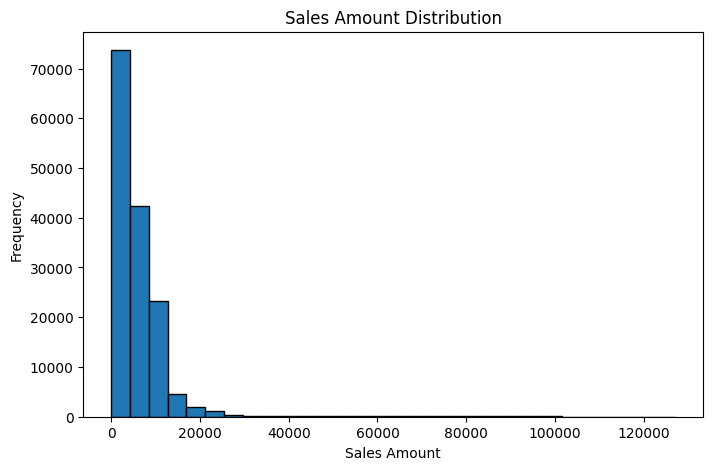

In [34]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,5))
plt.hist(df["Sales_Amount"], bins=30, edgecolor = "black")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.title("Sales Amount Distribution")
plt.show()

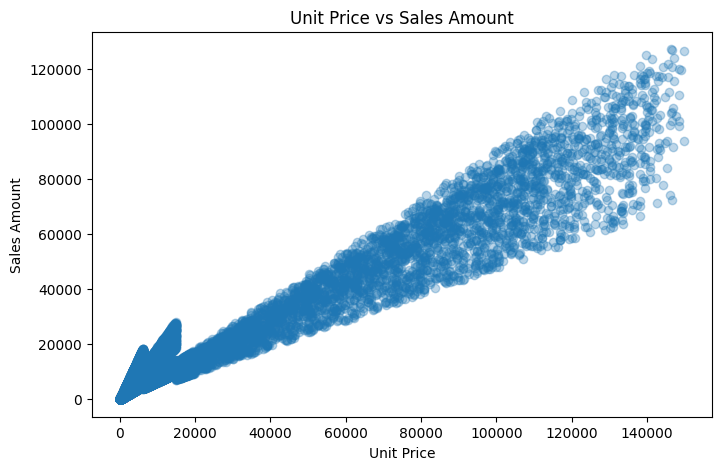

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(df["unit_price"], df["Sales_Amount"], alpha=0.3)
plt.xlabel("Unit Price")
plt.ylabel("Sales Amount")
plt.title("Unit Price vs Sales Amount")
plt.show()

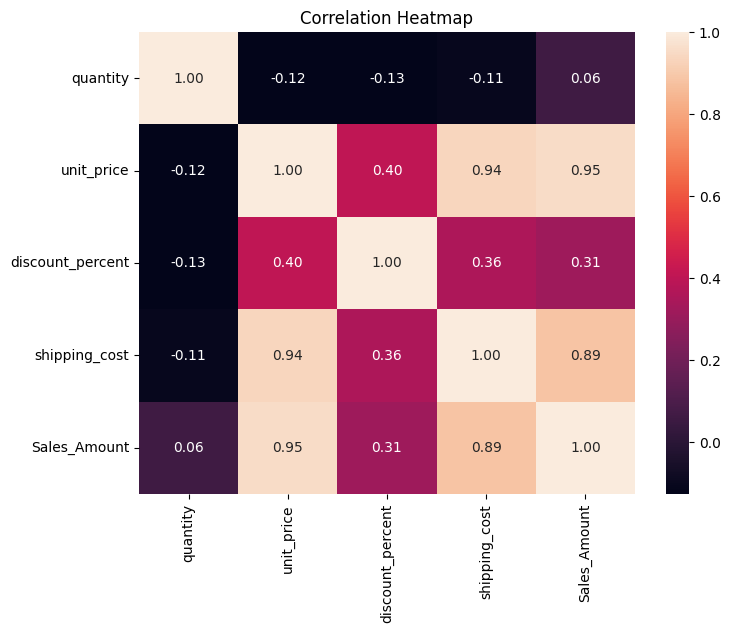

In [36]:
import seaborn as sns

numeric_cols = [
    "quantity",
    "unit_price",
    "discount_percent",
    "shipping_cost",
    "Sales_Amount"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

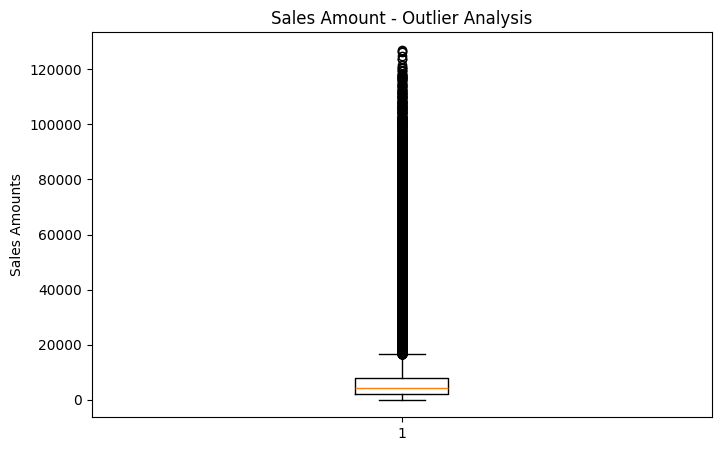

In [37]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Sales_Amount"])
plt.ylabel("Sales Amounts")
plt.title("Sales Amount - Outlier Analysis")
plt.show()

INSIGHT INTERPRETATION:
Pricing Impact: Unit Price and Sales Amount have a strong positive correlation of 0.95, indicating that higher-priced products are strongly associated with higher sales.

Top Categories: Furniture_Decor and Bed_Bath_Table are the top-performing categories by total sales.

Customer Behaviour: New customers contribute the highest total sales, mainly due to their higher transaction volume.

Regional Performance: South has the highest total sales, followed closely by North.

Payment Preference: UPI contributes the highest total sales among payment methods.

Low Quantity Pattern: Average quantity is 1.28, while its correlation with Sales Amount is only 0.06, showing a very weak linear relationship.

Operational Insight: Around 85% of orders are delivered, while approximately 7% are returned, making returns an area for further investigation.

Outliers: Sales Amount, Unit Price, and Shipping Cost contain high-value outliers that should be monitored rather than automatically removed.

Customer Satisfaction: Low-rated products can still generate substantial sales, indicating that high sales do not necessarily imply high customer satisfaction.

Sales Trend: Sales show overall growth across completed years; the latest-year decline should be interpreted carefully if the data is incomplete.

Conclusion:
The Python EDA revealed important patterns in sales, customer behaviour, regional performance, payment preferences, and product pricing. Higher-priced products are strongly associated with higher sales, while quantity has a weak relationship with sales. The analysis also identified high-value outliers and areas such as returns and customer ratings that require further investigation.